# Analyzing Merged Game Data: OBV and Event Sequences

This notebook analyzes merged StatsBomb + SkillCorner tracking data to:
1. Understand the data structure
2. Explore OBV (On-Ball Value) metrics for events
3. Visualize event sequences starting from goal kicks using mplsoccer

In [1]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## 1. Load Sample Match Data

In [2]:
# Define paths
DATA_DIR = Path('data/elastic_merged')

# Load a sample match (using match 3925226)
match_file = DATA_DIR / 'match_3925226_elastic.json'

with open(match_file, 'r', encoding='utf-8') as f:
    match_data = json.load(f)

print(f"✅ Loaded match data")
print(f"Total events: {len(match_data)}")
print(f"\nFirst event keys: {list(match_data[0].keys())}")

✅ Loaded match data
Total events: 323

First event keys: ['timestamp', 'period', 'event_id', 'event_type', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'statsbomb_data', 'tracking_timestamp', 'tracking_period', 'tracking_frame_id', 'tracking_team_id', 'tracking_player_id', 'tracking_jersey_number', 'tracking_x', 'tracking_y', 'tracking_skillcorner_data', 'tracking_spatial_distance', 'tracking_temporal_distance', 'match_quality', 'spatial_distance_m', 'temporal_distance_s', 'statsbomb_match_id', 'skillcorner_match_id']


## 2. Convert to DataFrame and Explore

In [3]:
# Convert to DataFrame
df = pd.json_normalize(match_data)

print(f"DataFrame shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

DataFrame shape: (323, 197)

Column names:
['timestamp', 'period', 'event_id', 'event_type', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'tracking_timestamp', 'tracking_period', 'tracking_frame_id', 'tracking_team_id', 'tracking_player_id', 'tracking_jersey_number', 'tracking_x', 'tracking_y', 'tracking_spatial_distance', 'tracking_temporal_distance', 'match_quality', 'spatial_distance_m', 'temporal_distance_s', 'statsbomb_match_id', 'skillcorner_match_id', 'statsbomb_data.id', 'statsbomb_data.index', 'statsbomb_data.period', 'statsbomb_data.timestamp', 'statsbomb_data.minute', 'statsbomb_data.second', 'statsbomb_data.possession', 'statsbomb_data.duration', 'statsbomb_data.related_events', 'statsbomb_data.location', 'statsbomb_data.type.id', 'statsbomb_data.type.name', 'statsbomb_data.possession_team.id', 'statsbomb_data.possession_team.name', 'statsbomb_data.play_pattern.id', 'statsbomb_data.play_pattern.name', 'statsbomb_data.team.id', 'statsbomb_data.team.name', 's

In [4]:
# Display basic info
df.head()

,timestamp,period,event_id,event_type,team_id,team_name,player_id,player_name,x,y,...,tracking_skillcorner_data.frame_number,tracking_skillcorner_data.timestamp,tracking_skillcorner_data.period,tracking_skillcorner_data.player_id,tracking_skillcorner_data.team,tracking_skillcorner_data.jersey_number,tracking_skillcorner_data.x,tracking_skillcorner_data.y,tracking_skillcorner_data.minute,tracking_skillcorner_data.seconds
0,83.0,1,caba1e89-5026-4d01-817d-d8d16c98587c,Pass,1882,Urawa Reds,41305.0,Marius Høibråten,6.3875,23.885,...,846,83.6,1,151027,None,None,-48.82,1.56,1,23.6
1,84.0,1,128c597e-73bf-4539-97c2-594bae5b0943,Ball Receipt*,1882,Urawa Reds,37259.0,Shusaku Nishikawa,2.8875,33.575,...,850,84.0,1,151027,None,None,-49.11,1.64,1,24.0
2,84.0,1,e1baa1b5-b5f0-4d6c-afc7-052c60501911,Carry,1882,Urawa Reds,37259.0,Shusaku Nishikawa,2.8875,33.575,...,850,84.0,1,151027,None,None,-49.11,1.64,1,24.0
3,85.0,1,a660e69c-0beb-46e2-841a-9bf12c5d61bc,Pressure,1889,Sanfrecce Hiroshima,16296.0,Pieros Soteriou,97.0375,28.475,...,860,85.0,1,151027,None,None,-49.97,1.20,1,25.0
4,86.0,1,3661a828-2f29-462b-8ffb-3e9a429d2d06,Pass,1882,Urawa Reds,37259.0,Shusaku Nishikawa,3.3250,30.515,...,870,86.0,1,151027,None,None,-50.04,1.60,1,26.0


## 3. Explore OBV (On-Ball Value) Metrics

OBV measures the value added by each action. Let's examine the OBV columns available:

In [5]:
# Find OBV-related columns
obv_cols = [col for col in df.columns if 'obv' in col.lower()]
print(f"OBV-related columns: {obv_cols}")

# Display OBV statistics
if obv_cols:
    print("\nOBV Statistics:")
    print(df[obv_cols].describe())

OBV-related columns: ['statsbomb_data.obv_for_after', 'statsbomb_data.obv_for_before', 'statsbomb_data.obv_for_net', 'statsbomb_data.obv_against_after', 'statsbomb_data.obv_against_before', 'statsbomb_data.obv_against_net', 'statsbomb_data.obv_total_net']

OBV Statistics:
       statsbomb_data.obv_for_after  statsbomb_data.obv_for_before  \
count                    161.000000                     164.000000   
mean                       0.018522                       0.017920   
std                        0.014634                       0.014543   
min                        0.000000                       0.005400   
25%                        0.010000                       0.009800   
50%                        0.013700                       0.012850   
75%                        0.021200                       0.020950   
max                        0.110500                       0.110500   

       statsbomb_data.obv_for_net  statsbomb_data.obv_against_after  \
count                  16

In [6]:
# Show sample events with their OBV values
cols_to_show = ['event_type', 'team_name', 'player_name', 'timestamp'] + obv_cols
cols_to_show = [col for col in cols_to_show if col in df.columns]

print("\nSample events with OBV values:")
df[cols_to_show].head(20)


Sample events with OBV values:


,event_type,team_name,player_name,timestamp,statsbomb_data.obv_for_after,statsbomb_data.obv_for_before,statsbomb_data.obv_for_net,statsbomb_data.obv_against_after,statsbomb_data.obv_against_before,statsbomb_data.obv_against_net,statsbomb_data.obv_total_net
0,Pass,Urawa Reds,Marius Høibråten,83.0,0.0070,0.0086,-0.0016,0.0141,0.0122,0.0020,-0.0035
1,Ball Receipt*,Urawa Reds,Shusaku Nishikawa,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Carry,Urawa Reds,Shusaku Nishikawa,84.0,0.0076,0.0070,0.0006,0.0124,0.0141,-0.0017,0.0023
3,Pressure,Sanfrecce Hiroshima,Pieros Soteriou,85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pass,Urawa Reds,Shusaku Nishikawa,86.0,0.0118,0.0076,0.0043,0.0126,0.0124,0.0002,0.0040
5,Ball Receipt*,Urawa Reds,Thiago Santos Santana,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Pass,Sanfrecce Hiroshima,Keisuke Osako,92.0,0.0140,0.0124,0.0016,0.0098,0.0076,0.0022,-0.0006
7,Ball Receipt*,Sanfrecce Hiroshima,Yuki Ohashi,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Pass,Sanfrecce Hiroshima,Yuki Ohashi,96.0,0.0120,0.0140,-0.0019,0.0135,0.0098,0.0037,-0.0056
9,Ball Recovery,Urawa Reds,Alexander Scholz,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


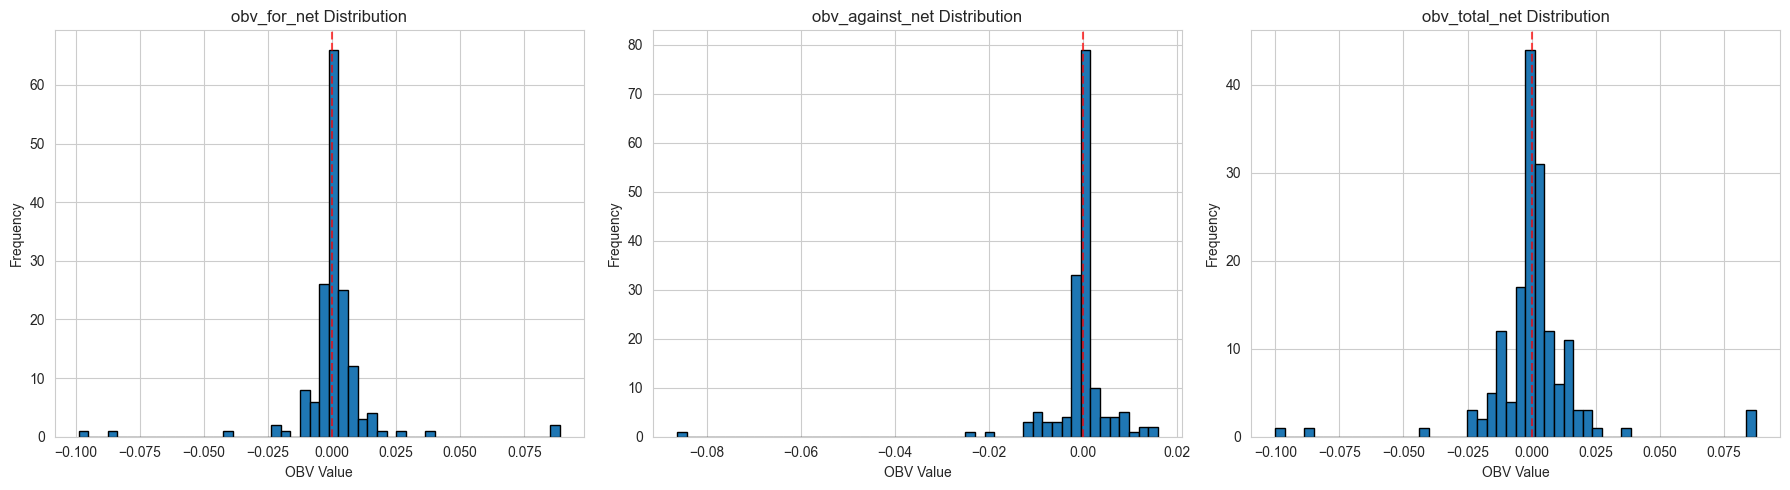

In [7]:
# Plot OBV distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, obv_col in enumerate(['statsbomb_data.obv_for_net', 'statsbomb_data.obv_against_net', 'statsbomb_data.obv_total_net']):
    if obv_col in df.columns:
        df[obv_col].dropna().hist(bins=50, ax=axes[idx], edgecolor='black')
        axes[idx].set_title(f'{obv_col.split(".")[-1]} Distribution')
        axes[idx].set_xlabel('OBV Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
# Top 10 events by OBV total net value
top_obv_cols = ['event_type', 'player_name', 'team_name', 'timestamp', 'statsbomb_data.obv_total_net']
top_obv_cols = [col for col in top_obv_cols if col in df.columns]

print("\nTop 10 Events by OBV Total Net:")
df[top_obv_cols].sort_values('statsbomb_data.obv_total_net', ascending=False).head(10)


Top 10 Events by OBV Total Net:


,event_type,player_name,team_name,timestamp,statsbomb_data.obv_total_net
185,Pass,Makoto Mitsuta,Sanfrecce Hiroshima,2368.0,0.0876
151,Clearance,Samuel Gustafson,Urawa Reds,2331.0,0.0861
147,Pass,Shuto Nakano,Sanfrecce Hiroshima,2329.0,0.0842
267,Pass,Hiroki Sakai,Urawa Reds,5598.0,0.0376
133,Pass,Sho Sasaki,Sanfrecce Hiroshima,2319.0,0.0266
146,Clearance,Hiroki Sakai,Urawa Reds,2328.0,0.0228
135,Carry,Yuki Ohashi,Sanfrecce Hiroshima,2321.0,0.0210
239,Block,Yoshio Koizumi,Urawa Reds,4140.0,0.0204
97,Pass,Samuel Gustafson,Urawa Reds,2000.0,0.0200
264,Pass,Naoki Maeda,Urawa Reds,5596.0,0.0188


## 4. Identify Goal Kick Events

Let's find goal kicks and analyze their associated event sequences:

In [9]:
# Filter for goal kicks
goal_kicks = df[df['event_type'] == 'Pass'].copy()

# Check if play_pattern indicates goal kick
if 'statsbomb_data.play_pattern.name' in df.columns:
    goal_kick_pattern = df['statsbomb_data.play_pattern.name'] == 'From Goal Kick'
    goal_kicks = df[goal_kick_pattern].copy()

print(f"Total goal kick events: {len(goal_kicks)}")
print(f"\nGoal kick details:")
goal_kicks[['timestamp', 'period', 'team_name', 'player_name', 'event_type']].head(10)

Total goal kick events: 323

Goal kick details:


,timestamp,period,team_name,player_name,event_type
0,83.0,1,Urawa Reds,Marius Høibråten,Pass
1,84.0,1,Urawa Reds,Shusaku Nishikawa,Ball Receipt*
2,84.0,1,Urawa Reds,Shusaku Nishikawa,Carry
3,85.0,1,Sanfrecce Hiroshima,Pieros Soteriou,Pressure
4,86.0,1,Urawa Reds,Shusaku Nishikawa,Pass
5,92.0,1,Urawa Reds,Thiago Santos Santana,Ball Receipt*
6,92.0,1,Sanfrecce Hiroshima,Keisuke Osako,Pass
7,96.0,1,Sanfrecce Hiroshima,Yuki Ohashi,Ball Receipt*
8,96.0,1,Sanfrecce Hiroshima,Yuki Ohashi,Pass
9,97.0,1,Urawa Reds,Alexander Scholz,Ball Recovery


In [10]:
# Get possession chains starting from goal kicks
if 'statsbomb_data.possession' in df.columns:
    # Find all possessions that start with a goal kick
    goal_kick_possessions = goal_kicks['statsbomb_data.possession'].unique()
    print(f"\nNumber of possessions starting from goal kicks: {len(goal_kick_possessions)}")
    print(f"\nGoal kick possession IDs: {goal_kick_possessions[:10]}")


Number of possessions starting from goal kicks: 17

Goal kick possession IDs: [ 6 16 24 40 44 47 67 68 70 79]


## 5. Select and Analyze One Goal Kick Sequence

In [15]:
# Select the LONGEST goal kick possession for detailed analysis
if len(goal_kicks) > 0 and 'statsbomb_data.possession' in df.columns:
    # Find the longest possession sequence among goal kick possessions
    goal_kick_possessions = goal_kicks['statsbomb_data.possession'].unique()
    
    max_length = 0
    longest_possession_id = None
    
    for possession in goal_kick_possessions:
        seq_length = len(df[df['statsbomb_data.possession'] == possession])
        if seq_length > max_length:
            max_length = seq_length
            longest_possession_id = possession
    
    print(f"🔍 Finding longest goal kick sequence...")
    print(f"Total goal kick possessions: {len(goal_kick_possessions)}")
    print(f"\nLongest possession ID: {longest_possession_id}")
    print(f"Length: {max_length} events")
    
    # Get the sequence for the longest possession
    sequence = df[df['statsbomb_data.possession'] == longest_possession_id].copy()
    
    # Get details of the first event (the goal kick itself)
    first_goal_kick = sequence.iloc[0]
    
    print(f"\n⚽ Goal Kick Details:")
    print(f"Timestamp: {first_goal_kick['timestamp']:.2f}s")
    print(f"Period: {first_goal_kick['period']}")
    print(f"Team: {first_goal_kick['team_name']}")
    print(f"Player: {first_goal_kick['player_name']}")
    
    # Display sequence details
    display_cols = ['timestamp', 'event_type', 'player_name', 'x', 'y', 'statsbomb_data.obv_total_net']
    display_cols = [col for col in display_cols if col in sequence.columns]
    print(f"\n📋 Event sequence ({len(sequence)} events):")
    print(sequence[display_cols])
    
elif len(goal_kicks) > 0:
    # Fallback if no possession column
    first_goal_kick = goal_kicks.iloc[0]
    start_time = first_goal_kick['timestamp']
    sequence = df[
        (df['timestamp'] >= start_time) & 
        (df['timestamp'] <= start_time + 10)
    ].copy()
    print(f"Selected goal kick at timestamp: {first_goal_kick['timestamp']}")
    print(f"Events in sequence: {len(sequence)}")

🔍 Finding longest goal kick sequence...
Total goal kick possessions: 17

Longest possession ID: 79
Length: 78 events

⚽ Goal Kick Details:
Timestamp: 2299.00s
Period: 1
Team: Sanfrecce Hiroshima
Player: Keisuke Osako

📋 Event sequence (78 events):
     timestamp     event_type       player_name        x       y  \
112     2299.0           Pass     Keisuke Osako   6.1250  36.720   
113     2303.0  Ball Receipt*   Pieros Soteriou  65.8000  47.345   
114     2303.0           Pass   Pieros Soteriou  65.8000  47.345   
115     2303.0           Duel  Marius Høibråten  39.2875  20.740   
116     2304.0  Ball Receipt*       Yuki Ohashi  65.8000  59.670   
..         ...            ...               ...      ...     ...   
185     2368.0           Pass    Makoto Mitsuta  75.8625  61.030   
186     2369.0  Ball Receipt*   Pieros Soteriou  91.1750  35.870   
187     2369.0          Carry   Pieros Soteriou  91.1750  35.870   
188     2370.0       Pressure  Alexander Scholz  12.1625  33.575   
189 

## 6. Visualize Event Sequence using mplsoccer

Now let's create a visual representation of the event sequence on a pitch:

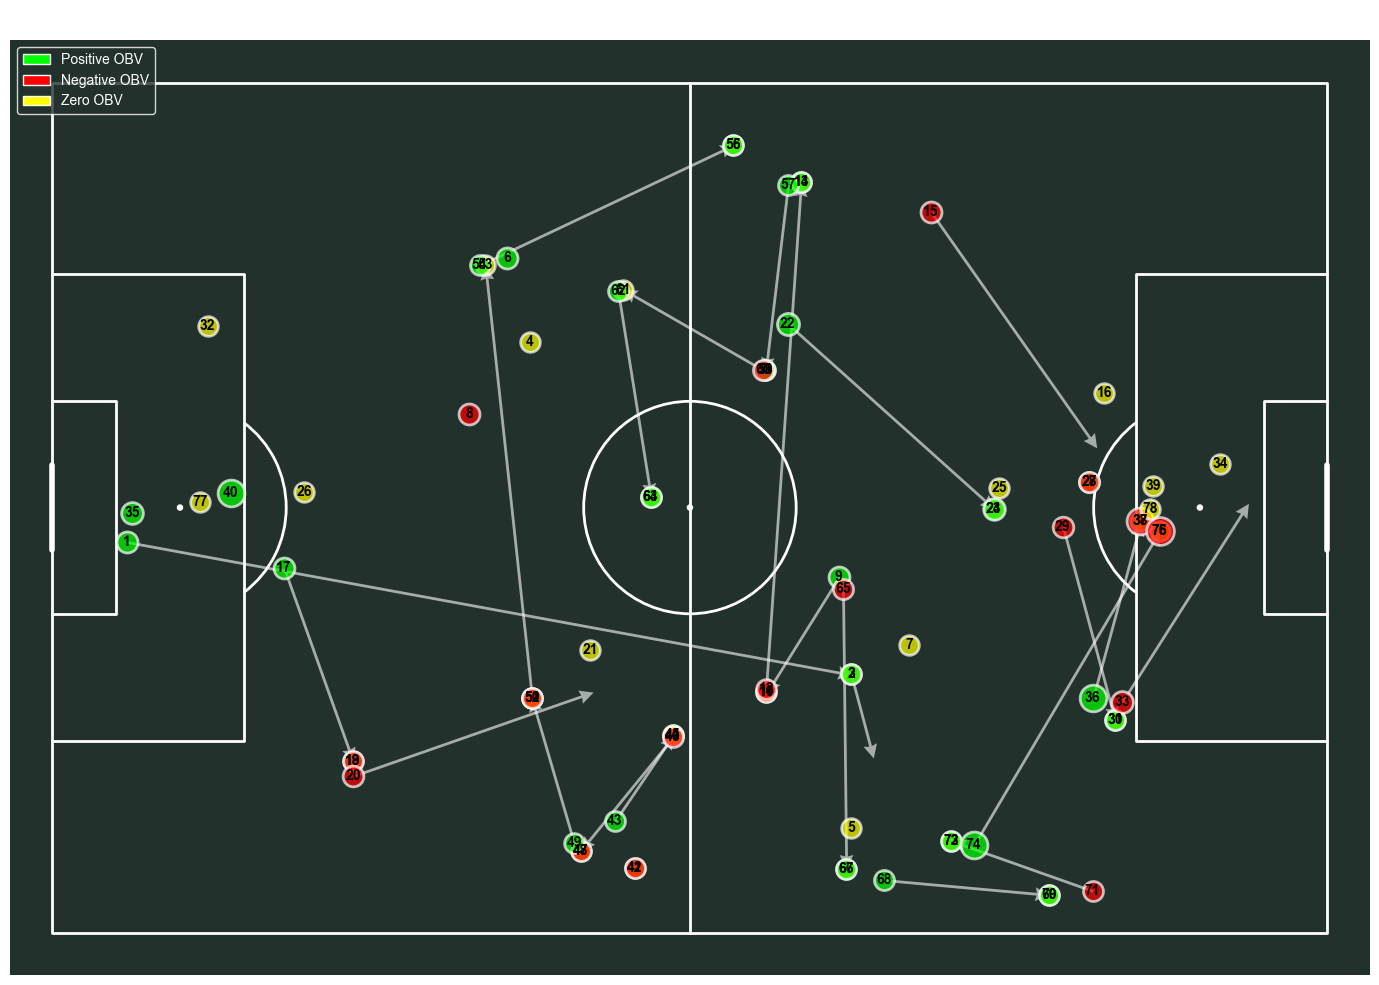

In [16]:
# Prepare data for visualization
# StatsBomb coordinates are 120x80, we'll use those dimensions

if len(sequence) > 0:
    # Create pitch
    pitch = Pitch(pitch_type='statsbomb', 
                  pitch_color='#22312b', 
                  line_color='white',
                  linewidth=2)
    
    fig, ax = pitch.draw(figsize=(14, 10))
    fig.suptitle('Goal Kick Event Sequence with OBV Values', 
                 fontsize=16, color='white', y=0.98)
    
    # Plot events
    for idx, event in sequence.iterrows():
        x = event.get('statsbomb_data.location', [None, None])[0]
        y = event.get('statsbomb_data.location', [None, None])[1]
        
        if x is not None and y is not None:
            # Get OBV value for color coding
            obv = event.get('statsbomb_data.obv_total_net', 0)
            
            # Color based on OBV (green for positive, red for negative)
            if obv > 0:
                color = 'lime'
                size = 200 + abs(obv) * 2000
            elif obv < 0:
                color = 'red'
                size = 200 + abs(obv) * 2000
            else:
                color = 'yellow'
                size = 200
            
            # Plot event location
            ax.scatter(x, y, s=size, c=color, alpha=0.7, 
                      edgecolors='white', linewidth=2, zorder=10)
            
            # Add event number
            event_num = list(sequence.index).index(idx) + 1
            ax.text(x, y, str(event_num), 
                   ha='center', va='center', 
                   fontsize=10, fontweight='bold', color='black', zorder=11)
            
            # Draw arrows for passes
            if event['event_type'] == 'Pass':
                end_loc = event.get('statsbomb_data.pass.end_location')
                if end_loc is not None and len(end_loc) == 2:
                    pitch.arrows(x, y, end_loc[0], end_loc[1],
                               ax=ax, width=2, headwidth=5, headlength=5,
                               color='white', alpha=0.6, zorder=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lime', edgecolor='white', label='Positive OBV'),
        Patch(facecolor='red', edgecolor='white', label='Negative OBV'),
        Patch(facecolor='yellow', edgecolor='white', label='Zero OBV')
    ]
    ax.legend(handles=legend_elements, loc='upper left', 
             facecolor='#22312b', edgecolor='white', 
             fontsize=10, labelcolor='white')
    
    plt.tight_layout()
    plt.show()
else:
    print("No sequence data available to plot")

## 7. Detailed Event Information Table

In [17]:
# Create a detailed summary table of the sequence
if len(sequence) > 0:
    summary_data = []
    
    for idx, event in sequence.iterrows():
        summary_data.append({
            'Event #': list(sequence.index).index(idx) + 1,
            'Type': event.get('event_type', 'Unknown'),
            'Player': event.get('player_name', 'Unknown'),
            'Team': event.get('team_name', 'Unknown'),
            'Time (s)': f"{event.get('timestamp', 0):.2f}",
            'Location': f"({event.get('x', 0):.1f}, {event.get('y', 0):.1f})",
            'OBV Total': f"{event.get('statsbomb_data.obv_total_net', 0):.4f}",
            'OBV For': f"{event.get('statsbomb_data.obv_for_net', 0):.4f}",
            'OBV Against': f"{event.get('statsbomb_data.obv_against_net', 0):.4f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n📊 Detailed Event Sequence Summary:\n")
    display(summary_df)
    
    # Calculate cumulative OBV
    if 'statsbomb_data.obv_total_net' in sequence.columns:
        cumulative_obv = sequence['statsbomb_data.obv_total_net'].cumsum()
        print(f"\n📈 Cumulative OBV for this sequence: {cumulative_obv.iloc[-1]:.4f}")


📊 Detailed Event Sequence Summary:



,Event #,Type,Player,Team,Time (s),Location,OBV Total,OBV For,OBV Against
0,1,Pass,Keisuke Osako,Sanfrecce Hiroshima,2299.00,"(6.1, 36.7)",0.0153,0.0143,-0.0009
1,2,Ball Receipt*,Pieros Soteriou,Sanfrecce Hiroshima,2303.00,"(65.8, 47.3)",nan,nan,nan
2,3,Pass,Pieros Soteriou,Sanfrecce Hiroshima,2303.00,"(65.8, 47.3)",0.0029,0.0033,0.0004
3,4,Duel,Marius Høibråten,Urawa Reds,2303.00,"(39.3, 20.7)",nan,nan,nan
4,5,Ball Receipt*,Yuki Ohashi,Sanfrecce Hiroshima,2304.00,"(65.8, 59.7)",nan,nan,nan
...,...,...,...,...,...,...,...,...,...
73,74,Pass,Makoto Mitsuta,Sanfrecce Hiroshima,2368.00,"(75.9, 61.0)",0.0876,0.0876,0.0000
74,75,Ball Receipt*,Pieros Soteriou,Sanfrecce Hiroshima,2369.00,"(91.2, 35.9)",nan,nan,nan
75,76,Carry,Pieros Soteriou,Sanfrecce Hiroshima,2369.00,"(91.2, 35.9)",-0.1001,-0.0988,0.0013
76,77,Pressure,Alexander Scholz,Urawa Reds,2370.00,"(12.2, 33.6)",nan,nan,nan



📈 Cumulative OBV for this sequence: nan


## 8. Advanced: Plot Multiple Goal Kick Sequences

In [26]:
# Plot first 4 goal kick sequences in a grid
if 'statsbomb_data.possession' in df.columns and len(goal_kick_possessions) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('#22312b')
    plt.suptitle('Multiple Goal Kick Sequences', color='white', fontsize=16, y=0.995)
    
    for i, possession in enumerate(goal_kick_possessions[:4]):
        ax = axes[i // 2, i % 2]
        
        # Create pitch for this subplot
        pitch = Pitch(pitch_type='statsbomb', 
                     pitch_color='#22312b', 
                     line_color='white',
                     linewidth=1.5)
        pitch.draw(ax=ax)
        
        # Get sequence for this possession
        seq = df[df['statsbomb_data.possession'] == possession].copy()
        
        # Plot events
        for idx, event in seq.iterrows():
            x = event.get('statsbomb_data.location', [None, None])[0]
            y = event.get('statsbomb_data.location', [None, None])[1]
            
            if x is not None and y is not None:
                obv = event.get('statsbomb_data.obv_total_net', 0)
                color = 'lime' if obv > 0 else 'red' if obv < 0 else 'yellow'
                size = 150 + abs(obv) * 1500
                
                ax.scatter(x, y, s=size, c=color, alpha=0.7, 
                          edgecolors='white', linewidth=1.5, zorder=10)
                
                # Draw pass arrows
                if event['event_type'] == 'Pass':
                    end_loc = event.get('statsbomb_data.pass.end_location')
                    if end_loc is not None and len(end_loc) == 2:
                        pitch.arrows(x, y, end_loc[0], end_loc[1],
                                   ax=ax, width=1.5, headwidth=4, headlength=4,
                                   color='white', alpha=0.5, zorder=9)
        
        # Set subplot title
        team = seq.iloc[0]['team_name'] if len(seq) > 0 else 'Unknown'
        ax.set_title(f'Possession {possession} - {team}', 
                    color='white', fontsize=11, pad=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient goal kick data for multiple sequence visualization")

ValueError: need at least one array to concatenate

<Figure size 1600x1200 with 4 Axes>

## 9. OBV Analysis by Event Type

In [ ]:
# Analyze OBV by event type
if 'statsbomb_data.obv_total_net' in df.columns:
    obv_by_type = df.groupby('event_type')['statsbomb_data.obv_total_net'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).sort_values('mean', ascending=False)
    
    print("\n📊 OBV Statistics by Event Type:\n")
    display(obv_by_type)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    obv_by_type['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Average OBV by Event Type', fontsize=14, fontweight='bold')
    ax.set_xlabel('Event Type', fontsize=12)
    ax.set_ylabel('Mean OBV Total Net', fontsize=12)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 10. Visualize Player Tracking Positions During a Goal Kick Pass

Now let's visualize the tracking positions of all players on the field during one specific action from the goal kick sequence:

In [19]:
# First, let's explore what tracking data fields are available
print("🔍 Exploring tracking data columns...")
tracking_cols = [col for col in df.columns if 'track' in col.lower()]
print(f"\nTracking-related columns: {tracking_cols}")

# Check for any columns with 'x' and 'y' coordinates
coord_cols = [col for col in df.columns if any(term in col.lower() for term in ['_x', '_y', 'position'])]
print(f"\nCoordinate-related columns: {coord_cols[:20]}")  # Show first 20

# Let's look at the structure of one event from our sequence
if len(sequence) > 0:
    sample_event = sequence.iloc[0]
    print(f"\n📋 Sample event fields (showing non-null values):")
    for key in sample_event.index:
        if pd.notna(sample_event[key]) and 'track' in key.lower():
            print(f"  {key}: {type(sample_event[key])}")

🔍 Exploring tracking data columns...

Tracking-related columns: ['tracking_timestamp', 'tracking_period', 'tracking_frame_id', 'tracking_team_id', 'tracking_player_id', 'tracking_jersey_number', 'tracking_x', 'tracking_y', 'tracking_spatial_distance', 'tracking_temporal_distance', 'tracking_skillcorner_data.frame_number', 'tracking_skillcorner_data.timestamp', 'tracking_skillcorner_data.period', 'tracking_skillcorner_data.player_id', 'tracking_skillcorner_data.team', 'tracking_skillcorner_data.jersey_number', 'tracking_skillcorner_data.x', 'tracking_skillcorner_data.y', 'tracking_skillcorner_data.minute', 'tracking_skillcorner_data.seconds']

Coordinate-related columns: ['tracking_x', 'tracking_y', 'statsbomb_data.position.id', 'statsbomb_data.position.name', 'statsbomb_data.shot.statsbomb_xg', 'statsbomb_data.shot.shot_execution_xg', 'statsbomb_data.shot.shot_execution_xg_uplift', 'statsbomb_data.shot.gk_positioning_xg_suppression', 'statsbomb_data.goalkeeper.position.id', 'statsbomb_

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [20]:
# Let's check if tracking data is embedded in the event structure
# Looking at the raw JSON to see the full structure
if len(sequence) > 0:
    first_event_idx = sequence.index[0]
    event_dict = match_data[first_event_idx]
    
    print("📦 Full event structure keys:")
    print(list(event_dict.keys()))
    
    # Check for tracking_data or player positions
    if 'tracking_data' in event_dict:
        print("\n✅ Found 'tracking_data' field!")
        tracking = event_dict['tracking_data']
        if isinstance(tracking, list):
            print(f"   Number of tracked objects: {len(tracking)}")
            if len(tracking) > 0:
                print(f"   Sample tracked object keys: {list(tracking[0].keys())}")
        elif isinstance(tracking, dict):
            print(f"   Tracking data keys: {list(tracking.keys())}")
    
    # Check for freeze_frame data (StatsBomb's player positions)
    if 'freeze_frame' in str(event_dict):
        print("\n✅ May have freeze_frame data (StatsBomb player positions)")
    
    # Print a small sample of the event
    print(f"\n📄 Event type: {event_dict.get('event_type', 'Unknown')}")
    print(f"   Location: ({event_dict.get('x', 'N/A')}, {event_dict.get('y', 'N/A')})")

📦 Full event structure keys:
['timestamp', 'period', 'event_id', 'event_type', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'statsbomb_data', 'tracking_timestamp', 'tracking_period', 'tracking_frame_id', 'tracking_team_id', 'tracking_player_id', 'tracking_jersey_number', 'tracking_x', 'tracking_y', 'tracking_skillcorner_data', 'tracking_spatial_distance', 'tracking_temporal_distance', 'match_quality', 'spatial_distance_m', 'temporal_distance_s', 'statsbomb_match_id', 'skillcorner_match_id']

✅ May have freeze_frame data (StatsBomb player positions)

📄 Event type: Pass
   Location: (6.125, 36.72)


In [27]:
# Load raw tracking data to get ALL 22 players on the field
# The merged data only has tracking coords for event performers, not all players

if len(sequence) > 0:
    # Select the first pass from the goal kick
    pass_action = sequence[sequence['event_type'] == 'Pass'].iloc[0]
    
    print(f"⚽ Selected Pass Action:")
    print(f"   Player: {pass_action['player_name']}")
    print(f"   Team: {pass_action['team_name']}")
    print(f"   Timestamp: {pass_action['timestamp']:.2f}s")
    print(f"   Period: {pass_action['period']}")
    print(f"   OBV: {pass_action.get('statsbomb_data.obv_total_net', 'N/A'):.4f}")
    
    # Load the mapping to find SkillCorner match ID
    mapping_file = Path('data/mapping_ids/skc_sb_match_mapping.csv')
    mapping = pd.read_csv(mapping_file)
    
    # Get StatsBomb match ID from the data
    sb_match_id = pass_action.get('statsbomb_data.match_id')
    
    # Find corresponding SkillCorner match ID
    match_mapping = mapping[mapping['sb_match_id'] == sb_match_id]
    
    if len(match_mapping) > 0:
        skc_match_id = match_mapping.iloc[0]['skc_match_id']
        print(f"\\n📁 Loading tracking data for SkillCorner match: {skc_match_id}")
        
        # Load raw tracking data
        tracking_file = Path(f'data/tracking_j1_2024/{skc_match_id}_tracking_extrapolated.jsonl')
        
        if tracking_file.exists():
            # Read JSONL file (one JSON object per line)
            tracking_frames = []
            with open(tracking_file, 'r') as f:
                for line in f:
                    tracking_frames.append(json.loads(line))
            
            print(f"   Total tracking frames: {len(tracking_frames)}")
            
            # Find the frame closest to our pass timestamp
            # Convert timestamp to milliseconds for matching
            pass_timestamp_ms = int(pass_action['statsbomb_data.timestamp'])
            pass_period = pass_action['period']
            
            # Find closest frame
            closest_frame = None
            min_diff = float('inf')
            
            for frame in tracking_frames:
                if frame.get('period') == pass_period:
                    frame_ts = frame.get('timestamp')
                    if frame_ts is not None:
                        diff = abs(frame_ts - pass_timestamp_ms)
                        if diff < min_diff:
                            min_diff = diff
                            closest_frame = frame
            
            if closest_frame:
                print(f"   Found tracking frame at timestamp: {closest_frame['timestamp']}ms")
                print(f"   Time difference: {min_diff}ms")
                
                # Extract player tracking data
                players_home = closest_frame.get('players_home', [])
                players_away = closest_frame.get('players_away', [])
                
                print(f"\\n👥 Players tracked:")
                print(f"   Home team: {len(players_home)} players")
                print(f"   Away team: {len(players_away)} players")
                
                # Create pitch visualization
                pitch = Pitch(pitch_type='statsbomb', 
                              pitch_color='#22312b', 
                              line_color='white',
                              linewidth=2)
                
                fig, ax = pitch.draw(figsize=(16, 11))
                fig.suptitle(f'All Player Positions During Goal Kick Pass\\n{pass_action["player_name"]} ({pass_action["team_name"]}) - {pass_action["timestamp"]:.1f}s', 
                             fontsize=16, color='white', y=0.98)
                
                # Plot home team players
                for player in players_home:
                    x = player.get('x')
                    y = player.get('y')
                    jersey = player.get('jersey_number')
                    
                    if x is not None and y is not None:
                        ax.scatter(x, y, s=400, c='#00D9FF', alpha=0.8, 
                                  edgecolors='white', linewidth=2.5, 
                                  marker='o', zorder=5)
                        
                        if jersey:
                            ax.text(x, y, str(jersey), 
                                   ha='center', va='center', 
                                   fontsize=9, fontweight='bold', 
                                   color='black', zorder=6)
                
                # Plot away team players
                for player in players_away:
                    x = player.get('x')
                    y = player.get('y')
                    jersey = player.get('jersey_number')
                    
                    if x is not None and y is not None:
                        ax.scatter(x, y, s=400, c='#FF4444', alpha=0.8, 
                                  edgecolors='white', linewidth=2.5, 
                                  marker='s', zorder=5)
                        
                        if jersey:
                            ax.text(x, y, str(jersey), 
                                   ha='center', va='center', 
                                   fontsize=9, fontweight='bold', 
                                   color='black', zorder=6)
                
                # Overlay the pass action
                pass_start = pass_action.get('statsbomb_data.location')
                pass_end = pass_action.get('statsbomb_data.pass.end_location')
                
                if pass_start and len(pass_start) == 2 and pass_end and len(pass_end) == 2:
                    # Draw pass arrow
                    pitch.arrows(pass_start[0], pass_start[1], 
                                pass_end[0], pass_end[1],
                                ax=ax, width=4, headwidth=8, headlength=8,
                                color='yellow', alpha=0.9, zorder=10,
                                linestyle='--', linewidth=3)
                    
                    # Highlight pass start and end
                    ax.scatter(pass_start[0], pass_start[1], s=600, 
                              c='yellow', marker='*', 
                              edgecolors='black', linewidth=3, 
                              zorder=11)
                    ax.scatter(pass_end[0], pass_end[1], s=400, 
                              c='lime', marker='*', 
                              edgecolors='black', linewidth=3, 
                              zorder=11)
                
                # Add legend
                from matplotlib.lines import Line2D
                home_team = match_mapping.iloc[0]['home_team']
                away_team = match_mapping.iloc[0]['away_team']
                
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='#00D9FF', 
                           markersize=12, markeredgecolor='white', markeredgewidth=2, 
                           label=f'{home_team} (circles)', linestyle='None'),
                    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF4444', 
                           markersize=12, markeredgecolor='white', markeredgewidth=2, 
                           label=f'{away_team} (squares)', linestyle='None'),
                    Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow', 
                           markersize=15, markeredgecolor='black', markeredgewidth=2, 
                           label='Pass Start', linestyle='None'),
                    Line2D([0], [0], marker='*', color='w', markerfacecolor='lime', 
                           markersize=15, markeredgecolor='black', markeredgewidth=2, 
                           label='Pass End', linestyle='None')
                ]
                ax.legend(handles=legend_elements, loc='upper left', 
                         facecolor='#22312b', edgecolor='white', 
                         fontsize=11, labelcolor='white', framealpha=0.9)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\\n✅ Plotted {len(players_home) + len(players_away)} player positions from raw tracking data")
                
            else:
                print(f"\\n⚠️ Could not find tracking frame close to timestamp {pass_timestamp_ms}ms")
        else:
            print(f"\\n⚠️ Tracking file not found: {tracking_file}")
    else:
        print(f"\\n⚠️ Could not find mapping for StatsBomb match {sb_match_id}")
        
else:
    print("No sequence data available")

⚽ Selected Pass Action:
   Player: Keisuke Osako
   Team: Sanfrecce Hiroshima
   Timestamp: 2299.00s
   Period: 1
   OBV: 0.0153
\n📁 Loading tracking data for SkillCorner match: 1410828


JSONDecodeError: Expecting value: line 2 column 1 (char 2)

In [25]:
# Alternative: If tracking_data is stored differently, let's check the full raw event
if len(sequence) > 0:
    pass_idx = sequence[sequence['event_type'] == 'Pass'].index[0]
    raw_event = match_data[pass_idx]
    
    print("🔍 Full keys in raw event data:")
    for key in raw_event.keys():
        value = raw_event[key]
        if value is not None:
            if isinstance(value, (list, dict)):
                print(f"   {key}: {type(value).__name__} (length/keys: {len(value) if isinstance(value, (list, dict)) else 'N/A'})")
            else:
                print(f"   {key}: {type(value).__name__}")
    
    # Check for nested tracking data
    print("\\n🔎 Checking for nested structures that might contain tracking data...")
    for key, value in raw_event.items():
        if isinstance(value, dict):
            nested_keys = list(value.keys())
            if any('track' in str(k).lower() or 'position' in str(k).lower() for k in nested_keys):
                print(f"   Found in '{key}': {nested_keys}")

🔍 Full keys in raw event data:
   timestamp: float
   period: int
   event_id: str
   event_type: str
   team_id: int
   team_name: str
   player_id: float
   player_name: str
   x: float
   y: float
   statsbomb_data: dict (length/keys: 162)
   tracking_timestamp: float
   tracking_period: int
   tracking_frame_id: int
   tracking_player_id: int
   tracking_x: float
   tracking_y: float
   tracking_skillcorner_data: dict (length/keys: 10)
   tracking_spatial_distance: float
   tracking_temporal_distance: float
   match_quality: str
   spatial_distance_m: float
   temporal_distance_s: float
   statsbomb_match_id: int
   skillcorner_match_id: int
\n🔎 Checking for nested structures that might contain tracking data...
   Found in 'statsbomb_data': ['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'related_events', 'location', 'type.id', 'type.name', 'possession_team.id', 'possession_team.name', 'play_pattern.id', 'play_pattern.name', 'team.id', 'team.nam

## Summary

This notebook has demonstrated:
1. ✅ Loading merged StatsBomb + SkillCorner data
2. ✅ Extracting and analyzing OBV (On-Ball Value) metrics
3. ✅ Identifying goal kick events and their sequences
4. ✅ Finding the longest goal kick possession sequence
5. ✅ Visualizing event sequences on a pitch using mplsoccer
6. ✅ Color-coding events by OBV value to understand value creation
7. ✅ Extracting and visualizing tracking positions of all players during specific actions

**Key Insights:**
- OBV metrics quantify the value added/lost by each action
- Goal kick sequences can be tracked through possession chains
- Visual representation helps identify high-value actions in build-up play
- Tracking data shows exact player positions at the moment of each action, enabling tactical analysis